In [2]:
#Загрузка датасета
!wget http://www.soshnikov.com/permanent/data/petfaces.tar.gz
!tar xfz petfaces.tar.gz
!rm petfaces.tar.gz

--2025-04-15 00:56:40--  http://www.soshnikov.com/permanent/data/petfaces.tar.gz
Resolving www.soshnikov.com (www.soshnikov.com)... 79.137.227.122
Connecting to www.soshnikov.com (www.soshnikov.com)|79.137.227.122|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24483412 (23M) [application/x-tar]
Saving to: ‘petfaces.tar.gz’

petfaces.tar.gz     100%[===================>]  23.35M   645KB/s    in 38s     

2025-04-15 00:57:17 (635 KB/s) - ‘petfaces.tar.gz’ saved [24483412/24483412]



In [3]:
#Перечень модулей
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np
import tensorflow as tf
%pip install -q shwarsutils
import os
from sklearn.model_selection import train_test_split
from collections import Counter
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

  Preparing metadata (setup.py) ... done


In [4]:
#Функция отображения изображений
def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

In [5]:
#Обработка изображений (на 256х256 Google Collab выводит "Your session crashed after using all available RAM" batch_size = 16, Runtime type = T4 GPU)
image_dir = 'petfaces'
categories = os.listdir(image_dir)

images = []
labels = []

for label, category in enumerate(categories):
    category_dir = os.path.join(image_dir, category)
    if os.path.isdir(category_dir):
        for image_name in os.listdir(category_dir):
            image_path = os.path.join(category_dir, image_name)
            if image_path.endswith('.jpg') or image_path.endswith('.png'):
                image = Image.open(image_path)
                image = image.resize((128, 128))
                images.append(np.array(image))
                labels.append(label)

images = np.array(images)
labels = np.array(labels)

images = images.astype('float32') / 255.0

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(2568, 128, 128, 3) (2568,)
(643, 128, 128, 3) (643,)


In [6]:
#Аугментация
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1)
])

In [7]:
#Создание энкодера
input = tf.keras.Input(shape=(128,128,3))
x = tf.keras.layers.Conv2D(8,(3,3),activation='relu',padding='same')(input)
x = tf.keras.layers.MaxPooling2D(2,padding='same')(x)
x = tf.keras.layers.Conv2D(16,(3,3),activation='relu',padding='same')(x)
x = tf.keras.layers.MaxPooling2D(2,padding='same')(x)
x = tf.keras.layers.Conv2D(8,(3,3),activation='relu',padding='same')(x)
encoded = tf.keras.layers.MaxPooling2D(2,padding='same')(x)

encoder = tf.keras.models.Model(input,encoded)
encoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,552 (9.97 KB)

 Trainable params: 2,552 (9.97 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#Создание декодера
latent = tf.keras.Input(shape=(16,16,8))
x = tf.keras.layers.Conv2D(8,(3,3),activation='relu',padding='same')(latent)
x = tf.keras.layers.UpSampling2D(2)(x)
x = tf.keras.layers.Conv2D(16,(3,3),activation='relu',padding='same')(x)
x = tf.keras.layers.UpSampling2D(2)(x)
x = tf.keras.layers.Conv2D(8,(3,3),activation='relu',padding='same')(x)
x = tf.keras.layers.UpSampling2D(2)(x)
decoded = tf.keras.layers.Conv2D(3,(3,3),activation='sigmoid',padding='same')(x)

decoder = tf.keras.models.Model(latent,decoded)
decoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │           219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,131 (12.23 KB)

 Trainable params: 3,131 (12.23 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#Обучение модели

autoencoder = tf.keras.models.Model(input,decoder(encoder(input)))
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
x_train_ = np.reshape(x_train,(-1,128,128,3))
x_test_ = np.reshape(x_test,(-1,128,128,3))
autoencoder.fit(x_train_,x_train_,epochs=1000,batch_size=128,shuffle=True,validation_data=(x_test_,x_test_))

Epoch 1/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step - loss: 0.6926 - val_loss: 0.6765
Epoch 2/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.6530 - val_loss: 0.5941
Epoch 3/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.5848 - val_loss: 0.5723
Epoch 4/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.5687 - val_loss: 0.5670
Epoch 5/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.5653 - val_loss: 0.5615
Epoch 6/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.5598 - val_loss: 0.5598
Epoch 7/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.5577 - val_loss: 0.5573
Epoch 8/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.5538 - val_loss: 0.5551
Epoch 9/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.5522 - val_loss: 0.5543
Epoch 10/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.5530 - val_loss: 0.5521
Epoch 11/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.5487 - val_loss: 0.5507
Epoch 12/1000
21/21 ━━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


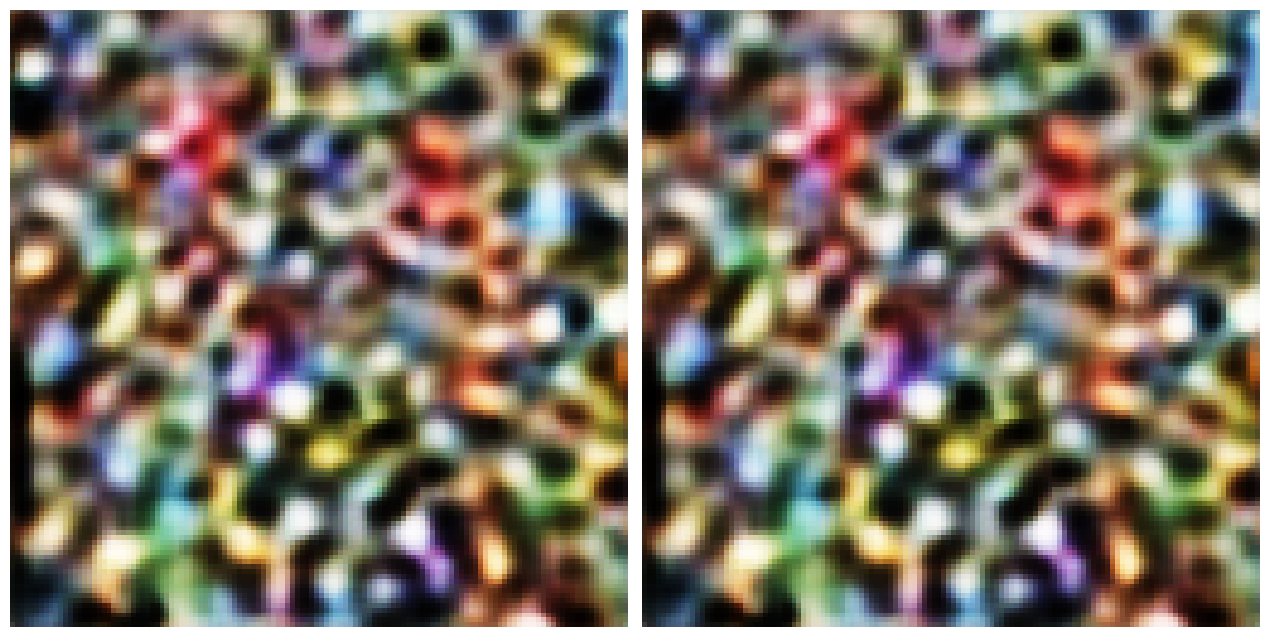

In [10]:
#Попытка генерации изображения по вектору
random_latent_vector = np.random.rand(1, 16, 16, 8)  # 1 изображение
generated_image = decoder.predict(random_latent_vector)
display_images([generated_image[0], generated_image[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


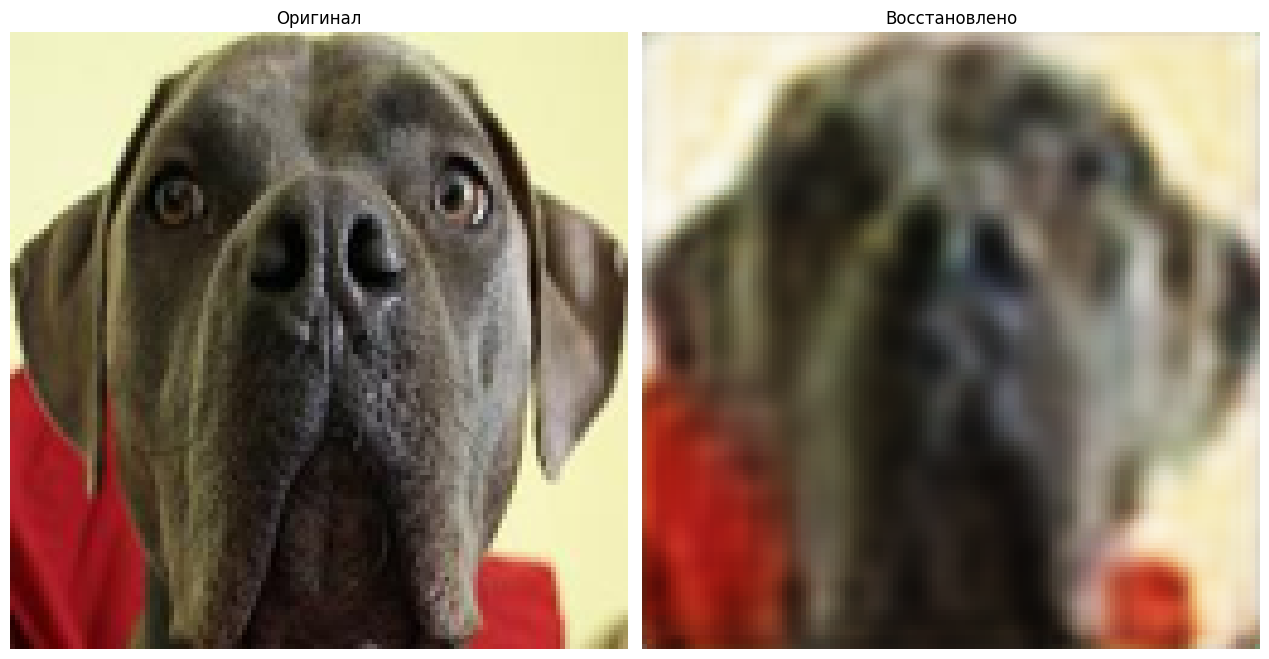

In [12]:
#Сжатие и восстановление
sample_image = x_test[0:1]
latent_vector = encoder.predict(sample_image)
reconstructed_image = decoder.predict(latent_vector)
display_images([sample_image[0], reconstructed_image[0]], titles=["Оригинал", "Восстановлено"])